In [1]:
%cd ..

c:\Users\almei\Documents\GitHub\research_ner_leaderboard


In [2]:
from pathlib import Path
import torch
import numpy as np
from transformers import AutoTokenizer
from transformers import AutoModelForTokenClassification, Trainer, TrainingArguments

from spesia_ner.metrics import compute_metrics
from spesia_ner.datasets import ClinicalRecordsDataset, DataCollatorForMultiLabelTokenClassification
from spesia_ner.trainers import MultiLabelTokenTrainer

model_id = "jhu-clsp/mmBERT-base"
dataset_path = Path("data/Spesia/doccano/annotated_records")

tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True)

labels_to_ignore = []
labels_to_consider = []

train_dataset = ClinicalRecordsDataset(
    dataset_path, 
    tokenizer, 
    split="train",
    tags_to_consider=labels_to_consider,
    labels_to_ignore=labels_to_ignore
    )

val_dataset = ClinicalRecordsDataset(
    dataset_path, 
    tokenizer, 
    split="val",
    tags_to_consider=labels_to_consider,
    labels_to_ignore=labels_to_ignore
    )

test_dataset = ClinicalRecordsDataset(
    dataset_path, 
    tokenizer, 
    split="test",
    tags_to_consider=labels_to_consider,
    labels_to_ignore=labels_to_ignore
    )

model = AutoModelForTokenClassification.from_pretrained(model_id, num_labels=train_dataset.num_labels)

Loading all Records: 100%|██████████| 1/1 [00:00<00:00, 19.99it/s]


Ignored labels during data split due to low sample count: []


Loading all Records: 100%|██████████| 1/1 [00:00<00:00, 30.56it/s]


Ignored labels during data split due to low sample count: []


Loading all Records: 100%|██████████| 1/1 [00:00<00:00, 28.22it/s]


Ignored labels during data split due to low sample count: []


Some weights of ModernBertForTokenClassification were not initialized from the model checkpoint at jhu-clsp/mmBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [3]:
train_dataset.get_label_count()

RE                        206
HER2                      203
HISTOPATHOLOGICAL_TYPE    201
RP                        198
SURGERY                   176
MENOPAUSE                 124
METASTASIS_PLACE           69
DISTANT_METASTASIS         41
BRCA                       34
FISH_CISH_SISH             18
dtype: int64

In [4]:
val_dataset.get_label_count()

HER2                      68
HISTOPATHOLOGICAL_TYPE    67
RP                        67
RE                        67
SURGERY                   59
MENOPAUSE                 45
METASTASIS_PLACE          20
DISTANT_METASTASIS        12
BRCA                      11
FISH_CISH_SISH             7
dtype: int64

In [5]:
test_dataset.get_label_count()

RE                        73
HER2                      72
RP                        70
HISTOPATHOLOGICAL_TYPE    68
SURGERY                   61
MENOPAUSE                 43
METASTASIS_PLACE          28
DISTANT_METASTASIS        19
BRCA                      17
FISH_CISH_SISH             7
dtype: int64

In [6]:
from spesia_ner.trainers import EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir="./output",
    per_device_train_batch_size=10,
    gradient_accumulation_steps=5,
    num_train_epochs=40,
    learning_rate=5e-5,
    include_for_metrics=['inputs'],
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)

data_collator = DataCollatorForMultiLabelTokenClassification(
    pad_token_id=tokenizer.pad_token_id,
    max_length=512,
    num_labels=train_dataset.num_labels
)

trainer = MultiLabelTokenTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(patience=5)],
    pos_weight=train_dataset.pos_weight
)

trainer.train()

Epoch,Training Loss,Validation Loss,Best Threshold,Macro Precision,Macro Recall,Macro F1,Macro Auc,Micro Precision,Micro Recall,Micro F1,Micro Auc
1,2.719700,0.512017,0.010000,0.009836,0.401824,0.017054,0.640319,0.008024,0.375284,0.015713,0.570992
2,0.438100,0.458588,0.010000,0.068763,0.440522,0.031103,0.788833,0.010067,0.353876,0.019576,0.645536
3,0.369300,0.378184,0.090000,0.347964,0.283214,0.135592,0.883518,0.099797,0.223159,0.137917,0.852714
4,0.254900,0.345111,0.080000,0.421592,0.376524,0.352482,0.944958,0.398302,0.349984,0.372583,0.942646
5,0.166900,0.397537,0.090000,0.571980,0.506451,0.496515,0.953427,0.590643,0.524165,0.555422,0.954434
6,0.107600,0.257982,0.160000,0.665437,0.590585,0.622272,0.981294,0.712758,0.605255,0.654622,0.983096
7,0.068300,0.216545,0.280000,0.696637,0.657677,0.662279,0.985855,0.711111,0.664288,0.686903,0.987766
8,0.052100,0.297039,0.220000,0.716375,0.697929,0.693699,0.986355,0.739046,0.738566,0.738806,0.979640
9,0.038800,0.266775,0.190000,0.728606,0.683882,0.703123,0.988099,0.775068,0.742134,0.758244,0.989835
10,0.032500,0.215861,0.230000,0.735297,0.695633,0.712041,0.990127,0.774493,0.730782,0.752003,0.992571


TrainOutput(global_step=126, training_loss=0.20828920722539937, metrics={'train_runtime': 225.1262, 'train_samples_per_second': 53.303, 'train_steps_per_second': 1.066, 'total_flos': 2146893493248000.0, 'train_loss': 0.20828920722539937, 'epoch': 21.0})

In [7]:
trainer.eval_dataset = test_dataset
trainer.evaluate()

{'eval_loss': 0.19304342567920685,
 'eval_best_threshold': 0.12,
 'eval_macro_precision': 0.6810981710938842,
 'eval_macro_recall': 0.7450981770859584,
 'eval_macro_f1': 0.6903983164413999,
 'eval_macro_auc': 0.9900490022497344,
 'eval_micro_precision': 0.6466431095406361,
 'eval_micro_recall': 0.773407022106632,
 'eval_micro_f1': 0.7043671354552183,
 'eval_micro_auc': 0.9894136068678987,
 'eval_runtime': 2.659,
 'eval_samples_per_second': 37.609,
 'eval_steps_per_second': 4.889,
 'epoch': 21.0}

In [8]:
# Get predictions object
pred_output = trainer.predict(test_dataset)

In [ ]:
from spesia_ner.metrics import compute_metrics_with_per_label_thresholds

compute_metrics_with_per_label_thresholds(pred_output, include_per_label_thresholds=True)

{'best_thresholds': array([0.79, 0.89, 0.07, 0.17, 0.07, 0.08, 0.9 , 0.14, 0.18, 0.19],
       dtype=float32),
 'best_thresholds_mean': 0.34800001978874207,
 'macro_precision': 0.762202813488821,
 'macro_recall': 0.7013554057730136,
 'macro_f1': 0.7237241961547889,
 'macro_auc': 0.9900490022497344,
 'micro_precision': 0.7589522546419099,
 'micro_recall': 0.744148244473342,
 'micro_f1': 0.7514773473407748,
 'micro_auc': 0.9894136068678987}

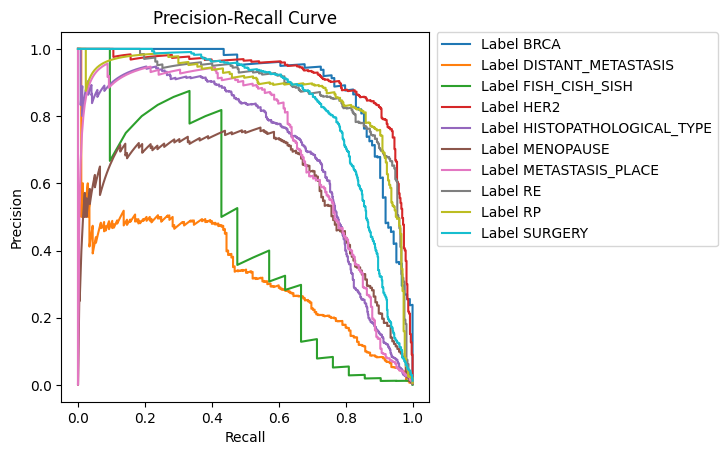

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Get probabilities (sigmoid for multilabel)
probs = 1 / (1 + np.exp(-pred_output.predictions))
labels = pred_output.label_ids.astype(int)

# For single-label: flatten arrays
if probs.shape[-1] == 1:
    probs_flat = probs.reshape(-1)
    labels_flat = labels.reshape(-1)
else:
    # For multilabel: plot for each label
    probs_flat = probs.reshape(-1, probs.shape[-1])
    labels_flat = labels.reshape(-1, labels.shape[-1])

# Plot for each label (or just one if single-label)
for i in range(probs_flat.shape[-1] if probs_flat.ndim > 1 else 1):
    if probs_flat.ndim > 1:
        y_score = probs_flat[:, i]
        y_true = labels_flat[:, i]
        label_name = f"Label {test_dataset.labels_to_consider[i]}"
    else:
        y_score = probs_flat
        y_true = labels_flat
        label_name = "Label"

    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    plt.plot(recall, precision, label=label_name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.subplots_adjust(right=0.7)  # make room on the right for the legend
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.show()

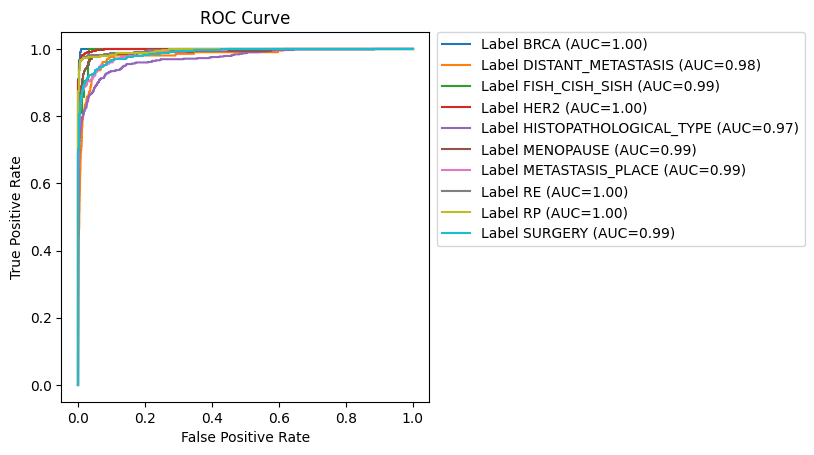

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Get probabilities (sigmoid for multilabel)
probs = 1 / (1 + np.exp(-pred_output.predictions))
labels = pred_output.label_ids.astype(int)

# For single-label: flatten arrays
if probs.shape[-1] == 1:
    probs_flat = probs.reshape(-1)
    labels_flat = labels.reshape(-1)
else:
    # For multilabel: plot for each label
    probs_flat = probs.reshape(-1, probs.shape[-1])
    labels_flat = labels.reshape(-1, labels.shape[-1])

# Plot ROC curve for each label (or just one if single-label)
for i in range(probs_flat.shape[-1] if probs_flat.ndim > 1 else 1):
    if probs_flat.ndim > 1:
        y_score = probs_flat[:, i]
        y_true = labels_flat[:, i]
        label_name = f"Label {test_dataset.labels_to_consider[i]}"
    else:
        y_score = probs_flat
        y_true = labels_flat
        label_name = "Label"

    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    plt.plot(fpr, tpr, label=f"{label_name} (AUC={auc:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.subplots_adjust(right=0.7)  # make room on the right for the legend
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.show()

In [11]:
trainer.save_model('best_model')